# IMDB 情感分析：Embedding + LSTM + Subword 分词

本 Notebook 展示如何使用 PyTorch 构建一个基于 **词嵌入 (Embedding) + LSTM** 的文本分类模型，
并采用 **BPE (Byte Pair Encoding) 子词分词** 处理 IMDB 电影评论数据集，完成二分类（正面 / 负面）任务。

**主要流程：**
1. 数据准备：使用 subword-nmt 进行 BPE 分词
2. 构建词表 & Tokenizer
3. 定义 LSTM 模型
4. 训练 & 可视化
5. 推理评估

## 一、导入依赖库

In [1]:
import matplotlib as mpl           # Matplotlib 绘图主模块
import matplotlib.pyplot as plt     # pyplot 提供类似 MATLAB 的绘图接口
%matplotlib inline                  
# Jupyter 魔法命令，使图形直接内嵌在 Notebook 中
import numpy as np                  # NumPy：高性能数值计算库
import sklearn                      # Scikit-learn：机器学习工具库（此处用于计算准确率）
import pandas as pd                 # Pandas：数据处理库，方便读写 CSV
import os                           # 操作系统接口，用于文件路径和目录操作
import sys                          # 系统相关参数，此处用于打印 Python 版本信息
import time                         # 时间模块，可用于计时
from tqdm import tqdm          # 进度条库，自动适配 Jupyter / 终端环境
import torch                        # PyTorch 深度学习框架主模块
import torch.nn as nn              # 神经网络模块，包含 Embedding、LSTM、Linear 等层
import torch.nn.functional as F    # 函数式接口，包含 binary_cross_entropy_with_logits 等损失函数

# 打印当前 Python 版本信息，方便环境核查
print(sys.version_info)
# 遍历主要依赖库，打印各自版本号
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

# 自动检测是否有可用 GPU；有则使用 cuda:0，否则退回 CPU
# device: torch.device 类型，后续张量和模型均 .to(device)
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)  # 输出当前计算设备

# 设置随机种子，保证实验可复现
seed = 42
torch.manual_seed(seed)            # 固定 PyTorch CPU 随机种子
torch.cuda.manual_seed_all(seed)   # 固定所有 GPU 随机种子
np.random.seed(seed)               # 固定 NumPy 随机种子


sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 二、加载 IMDB 数据集

通过 HuggingFace `datasets` 库加载 [stanfordnlp/imdb](https://huggingface.co/datasets/stanfordnlp/imdb) 数据集，该数据集包含 **50 000** 条英文电影评论，已划分为训练集 25 000 条、测试集 25 000 条；每条样本包含原始文本 `text` 与情感标签 `label`（0 = 负面，1 = 正面）。

### 2.1 从 HuggingFace 下载并缓存数据集

使用 `load_dataset` 接口自动下载数据到本地 `data/imdb` 缓存目录，避免重复联网。返回值为 `DatasetDict` 类型，可通过键名 `'train'`、`'test'` 访问各子集。

In [2]:
from datasets import load_dataset  # HuggingFace datasets 库：提供 load_dataset 统一数据加载接口

cache_dir = 'data/imdb'  # str：本地缓存目录路径，下载后的 Arrow 文件将保存在此

if not os.path.exists(cache_dir):   # os.path.exists(path) -> bool：判断目录是否已存在
    os.makedirs(cache_dir)          # os.makedirs(path)：递归创建目录（含父目录），已存在时不报错

# load_dataset(name, cache_dir) -> DatasetDict
#   name：数据集标识符，'stanfordnlp/imdb' 为 Stanford NLP 发布的 IMDB 影评数据集
#   cache_dir：指定缓存位置，第二次运行将直接读取本地文件，无需重新下载
dataset = load_dataset('stanfordnlp/imdb', cache_dir=cache_dir)

print(type(dataset))                   # 预期输出 DatasetDict，键为 split 名（'train'/'test'）
print(type(dataset['train']['text']))  # 预期输出 Column 类型，存储该列所有文本，支持索引访问

<class 'datasets.dataset_dict.DatasetDict'>
<class 'datasets.arrow_dataset.Column'>


### 2.2 提取训练集与测试集的文本和标签

将 `DatasetDict` 中各 split 的 `text`、`label` 列转为 NumPy 一维数组，便于后续向量化处理与文本清洗。`label` 为整数 0（负面）或 1（正面）。

In [3]:
# np.array(iterable) -> ndarray：将 Column / 列表转为 NumPy 数组，dtype 由元素类型自动推断
train_texts  = np.array(dataset['train']['text'])    # shape=(25000,)，元素为 str，训练集评论原文
train_labels = np.array(dataset['train']['label'])   # shape=(25000,)，元素为 int64，取值 0 或 1
test_texts   = np.array(dataset['test']['text'])     # shape=(25000,)，测试集评论原文
test_labels  = np.array(dataset['test']['label'])    # shape=(25000,)，测试集情感标签

# 验证数据形状是否符合预期（训练集和测试集各 25000 条）
print(f"训练集大小：{train_texts.shape}，标签：{train_labels.shape}")
print(f"测试集大小：{test_texts.shape}，标签：{test_labels.shape}")

训练集大小：(25000,)，标签：(25000,)
测试集大小：(25000,)，标签：(25000,)


### 2.3 文本清洗并保存训练/测试文本

参考词级分词 Notebook 的清洗逻辑：将标点替换为空格、合并连续空白，再将清洗后的训练集与测试集分别写入 `data/imdb_train.txt` 和 `data/imdb_test.txt`（每行一条评论，转小写），供后续 BPE 分词使用。

In [4]:
import re  # re：正则表达式模块，用于复杂字符串模式匹配与替换

def clean_text(text):
    """
    对单条评论做轻量文本清洗。

    参数:
        text (str): 原始电影评论字符串。

    返回:
        str: 清洗后的文本，首尾无多余空白，词与词之间以单个空格分隔。
    """
    text = text.replace(',', ' ').replace('.', ' ')  # 将逗号、句号替换为空格，弱化标点对分词的影响
    text = re.sub(r'\s+', ' ', text)  # re.sub(pattern, repl, s)：将连续空白合并为一个空格
    return text.strip()  # str.strip()：去除首尾空白字符，返回新字符串

# 列表推导式：对 train_texts / test_texts 中每条评论调用 clean_text，再封装为 NumPy 数组
train_texts = np.array([clean_text(t) for t in train_texts])  # shape 仍为 (25000,)，元素为清洗后的 str
test_texts  = np.array([clean_text(t) for t in test_texts])   # shape 仍为 (25000,)，测试集同样清洗

# 确保 data 目录存在，用于存放 BPE 所需的纯文本文件
data_dir = 'data'  # str：数据文件根目录
if not os.path.exists(data_dir):  # os.path.exists(path) -> bool：判断目录是否已存在
    os.makedirs(data_dir)         # os.makedirs(path)：递归创建目录

train_path = os.path.join(data_dir, 'imdb_train.txt')  # str：训练集纯文本路径
test_path  = os.path.join(data_dir, 'imdb_test.txt')   # str：测试集纯文本路径

# 将训练集写入 imdb_train.txt，每行一条评论（仅文本，不含 label）
with open(train_path, 'w', encoding='utf8') as file:
    for line in train_texts:              # 遍历训练集清洗后的评论
        file.write(line.lower() + '\n')    # 转小写并换行，减少词表中大小写重复

# 将测试集写入 imdb_test.txt
with open(test_path, 'w', encoding='utf8') as file:
    for line in test_texts:               # 遍历测试集清洗后的评论
        file.write(line.lower() + '\n')  # 同样转小写保存

# 构建 cleaned_df，供后续 BPE 分词结果与标签合并保存 CSV
cleaned_df = pd.DataFrame({
    'processed': np.concatenate([train_texts, test_texts]),  # 清洗后的评论文本，共 50000 条
    'label': np.concatenate([train_labels, test_labels])     # 对应情感标签，0=负面，1=正面
})

print(f'已保存训练集至 {train_path}，共 {len(train_texts)} 条')  # 预期 25000 条
print(f'已保存测试集至 {test_path}，共 {len(test_texts)} 条')    # 预期 25000 条
print(cleaned_df.shape)  # 预期 (50000, 2)

已保存训练集至 data\imdb_train.txt，共 25000 条
已保存测试集至 data\imdb_test.txt，共 25000 条
(50000, 2)


## 三、数据预处理与 BPE 分词

使用 [subword-nmt](https://github.com/rsennrich/subword-nmt) 在 `data/imdb_train.txt` 上学习 BPE 合并规则，并应用到训练集与测试集，得到子词级文本表示。

### 3.1 安装 subword-nmt

In [5]:
# 如未安装 subword-nmt，取消下行注释运行
# subword-nmt 是 BPE (Byte Pair Encoding) 分词的官方命令行工具
# !pip install subword-nmt


### 3.2 学习 BPE 分词规则

In [6]:
# 本单元目标：在训练语料上学习 BPE 合并规则，并导出子词词频表供后续构建词表。

# 定义输入训练文本路径（str）：每行一条评论，已完成基础清洗与小写化。
bpe_train_input_path = "data/imdb_train.txt"
# 定义 BPE 规则输出路径（str）：保存 merge rule，后续 apply-bpe 必须依赖该文件。
bpe_code_output_path = "data/imdb_bpe_code"
# 定义 BPE 词表输出路径（str）：保存子词及其频次，用于构建 word2idx。
bpe_vocab_output_path = "data/imdb_bpe_vocab"
# 定义合并步数（int）：步数越大，子词越趋向长片段，词表规模也会变化。
# 这里将 merge 步数从 8000 提升到 16000，减少过碎切分带来的序列膨胀。
bpe_merge_operations = 16000

# 说明：
# - `learn-joint-bpe-and-vocab` 会同时学习 merge 规则和词频词表。
# - `-i` 指定输入语料。
# - `-o` 指定 merge 规则文件。
# - `--write-vocabulary` 指定词频输出文件。
# - `-s` 指定 BPE merge 操作次数。
# 返回：该命令主要产生文件副作用，无 Python 返回值。
!subword-nmt learn-joint-bpe-and-vocab -i {bpe_train_input_path} -o {bpe_code_output_path} --write-vocabulary {bpe_vocab_output_path} -s {bpe_merge_operations}



100%|##########| 16000/16000 [00:14<00:00, 1119.88it/s]


### 3.3 应用 BPE 规则进行分词

In [7]:
# 本单元目标：将上一步学到的 BPE 合并规则应用到训练集与测试集，生成子词文本文件。

# 规则文件路径（str）：由 `learn-joint-bpe-and-vocab` 生成。
bpe_code_path = "data/imdb_bpe_code"
# 训练集输入/输出路径（str）：输出文件每行对应一条 BPE 子词序列。
train_raw_path = "data/imdb_train.txt"
train_bpe_output_path = "data/imdb_train_bpe.txt"
# 测试集输入/输出路径（str）。
test_raw_path = "data/imdb_test.txt"
test_bpe_output_path = "data/imdb_test_bpe.txt"

# 对训练集执行 BPE 分词：
# - `-c` 指定规则文件。
# - `-i` 指定原始文本输入。
# - `-o` 指定子词结果输出。
# 说明：被拆分词片段会带 `@@` 续写标记（如 `sum@@ mer@@ slam`）。
!subword-nmt apply-bpe -c {bpe_code_path} -i {train_raw_path} -o {train_bpe_output_path}

# 对测试集执行同样规则的 BPE 分词，确保训练/测试 token 空间一致。
!subword-nmt apply-bpe -c {bpe_code_path} -i {test_raw_path} -o {test_bpe_output_path}


### 3.4 查看 BPE 分词效果

In [8]:
# 本单元功能：在 Windows / Linux 均可稳定预览 BPE 分词文件前若干行，避免依赖 shell 的 head 命令。
# 接口说明：open(path, mode='r', encoding='utf8') -> TextIOWrapper，返回可迭代文件对象。
# 参数说明：preview_line_num (int) 控制预览行数；建议设置为 5~20，便于快速人工检查。
preview_line_num = 10

# 输入文件路径（str）：上一步 `apply-bpe` 生成的训练集子词文本文件。
bpe_preview_path = "data/imdb_train_bpe.txt"

# 使用 with 上下文安全打开文件：离开代码块后会自动关闭文件句柄，防止资源泄漏。
with open(bpe_preview_path, "r", encoding="utf8") as file:
    # enumerate(iterable, start=1) -> Iterator[Tuple[int, str]]：同时获得行号与行内容。
    for line_id, line in enumerate(file, start=1):
        # str.strip() -> str：去掉行尾换行符，输出更紧凑，便于 Notebook 中阅读。
        print(f"{line_id:02d}: {line.strip()}")
        # 当行号达到预览上限时提前停止循环，避免输出过长。
        if line_id >= preview_line_num:
            break

# 教学提示：若看到 token 末尾包含 @@，表示该 token 仍与后续子词片段属于同一个原始单词。
# 例如：sum@@ mer@@ slam 对应原词 summerslam，说明 BPE 将低频词拆成了更可复用的子词单元。


01: i rented i am curi@@ ous@@ -@@ yellow from my video store because of all the controversy that surrounded it when it was first released in 196@@ 7 i also heard that at first it was se@@ ized by u s custom@@ s if it ever tried to enter this country therefore being a fan of films considered "@@ controversi@@ al" i really had to see this for myself <br /><br />the plot is centered around a young swedish drama student named lena who wants to learn everything she can about life in particular she wants to focus her attenti@@ ons to making some sort of documentary on what the average swe@@ de thought about certain political issues such as the vietnam war and race issues in the united states in between asking politicians and ordinary den@@ iz@@ ens of stock@@ holm about their opinions on politics she has sex with her drama teacher classmates and married men <br /><br />what kills me about i am curi@@ ous@@ -@@ yellow is that 40 years ago this was considered pornographic really the sex and n

### 3.5 预览原始数据

In [9]:
# 预览 cleaned_df 前 5 行，查看 processed 列（原始文本）和 label 列（情感标签）
# 返回值：DataFrame，包含 processed（str）和 label（int: 0/1）两列
cleaned_df.head()


,processed,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,Oh brother after hearing about this ridiculous...,0


### 3.6 合并分词结果并保存 CSV

In [10]:
# 读取 BPE 分词文件并写入结构化 CSV（本代码单元主要执行数据落盘，无显式返回值）
# subwords: List[str]，用于顺序存放训练集与测试集的 BPE 分词文本（总长度应为 50000）
subwords = []

# open(file, mode, encoding) -> TextIOWrapper：打开训练集 BPE 文件，mode='r' 表示只读文本模式
with open("data/imdb_train_bpe.txt", "r", encoding="utf8") as file:
    # file.readlines() -> List[str]：一次性读取所有行；每行对应一条样本的子词序列字符串
    for line in file.readlines():
        # str.strip() -> str：去除行首行尾空白字符（尤其是行尾 '\n'），保持每条文本单行格式
        subwords.append(line.strip())

# 继续读取测试集 BPE 文件，并将内容按顺序追加到 subwords 末尾
with open("data/imdb_test_bpe.txt", "r", encoding="utf8") as file:
    # 逐行读取测试集文本，逻辑与训练集保持一致，保证两部分处理标准完全相同
    for line in file.readlines():
        # append(value) -> None：将当前样本写入列表，列表顺序与原文件顺序一致
        subwords.append(line.strip())

# 将 BPE 分词字符串写入 DataFrame 新列，列名 subwords10k 用于后续 Dataset 按列读取
cleaned_df["subwords10k"] = subwords

# 构造 split 列：前 25000 行标记为 train，后 25000 行标记为 test，便于后续按 split 过滤
cleaned_df["split"] = ["train"] * 25000 + ["test"] * 25000

# DataFrame.to_csv(path, index=False) -> None：保存为 CSV，index=False 表示不写入行索引列
cleaned_df.to_csv("data/imdb_subwords.csv", index=False)

# 打印结果形状用于校验：预期包含 processed、label、subwords10k、split 四列
print("imdb_subwords.csv 保存完成，当前数据形状:", cleaned_df.shape)


imdb_subwords.csv 保存完成，当前数据形状: (50000, 4)


### 3.7 构建 PyTorch Dataset

In [11]:
# 导入 PyTorch 数据接口：Dataset 用于定义“单样本读取规则”，DataLoader 用于“批量读取与并行加载”。
from torch.utils.data import Dataset, DataLoader

# 定义 IMDBDataset：职责是从 CSV 中读取指定 split，并在 `__getitem__` 时返回 (token_list, label)。
class IMDBDataset(Dataset):
    # 构造函数：在实例化时完成数据读取与缓存，避免每次取样本都重复读磁盘。
    def __init__(self, mode="train"):
        """
        功能：初始化 IMDB 子词数据集对象。

        参数：
            mode (str): 数据划分标识。
                - "train"：加载训练集样本。
                - "test"：加载测试集样本。

        返回：
            None。该函数不返回值，而是把读取结果保存到实例属性 `self.texts` 与 `self.labels`。
        """
        # 读取完整 CSV：pd.read_csv(path) -> DataFrame，包含 processed/label/subwords10k/split 等列。
        full_df = pd.read_csv("data/imdb_subwords.csv")
        # 按 split 过滤：DataFrame.query(expr) -> DataFrame，仅保留指定 mode 的子集。
        split_df = full_df.query("split == '{}'".format(mode))
        # 提取子词文本列：values -> np.ndarray，元素类型为 str，每个元素是一条“空格分隔”的子词序列。
        self.texts = split_df["subwords10k"].values
        # 提取标签列：values -> np.ndarray，元素为 0/1 整数，分别表示负面/正面情感。
        self.labels = split_df["label"].values

    # `__len__` 是 Dataset 的标准接口之一，供 DataLoader 知道样本总数。
    def __len__(self):
        """
        功能：返回当前数据集样本数量。

        参数：
            无。

        返回：
            int：样本总条数。
        """
        # len(self.labels) 与 len(self.texts) 应一致；这里以标签长度作为样本总数。
        return len(self.labels)

    # `__getitem__` 是 Dataset 的核心接口，DataLoader 会反复调用它来构建 batch。
    def __getitem__(self, idx):
        """
        功能：根据索引读取单条样本。

        参数：
            idx (int): 样本下标，取值范围通常为 [0, len(self)-1]。

        返回：
            Tuple[List[str], int]
                - 第 1 个元素：List[str]，由子词 token 构成的列表。
                - 第 2 个元素：int，二分类标签（0=负面，1=正面）。
        """
        # 读取第 idx 条文本（原始形态是“空格拼接”的字符串）。
        text = self.texts[idx]
        # 使用 split() 将字符串拆为 token 列表，作为模型编码输入。
        token_list = text.split()
        # 读取对应标签并显式转 int，避免后续 dtype 推断歧义。
        label = int(self.labels[idx])
        # 按约定返回二元组：(token_list, label)。
        return token_list, label


# 构建训练集对象：后续 DataLoader(train_ds, ...) 会据此批量读取训练样本。
train_ds = IMDBDataset("train")
# 构建测试集对象：用于训练过程中的验证评估和最终测试。
test_ds = IMDBDataset("test")


### 3.8 数据集样本结构检查

用于验证 `IMDBDataset.__getitem__` 的输出格式是否正确，确认返回值为“子词列表 + 标签”的二元组。

In [12]:
# 本单元目标：对 Dataset 的单样本输出做可解释性检查，确保下游 collate/Tokenizer 可以正确消费。
# 接口说明：train_ds[idx] 会调用 IMDBDataset.__getitem__(idx: int) -> Tuple[List[str], int]。

# 指定抽样索引（int）：这里读取训练集第 1 条样本，便于固定复现实验日志。
sample_index = 0
# 执行索引访问：返回二元组 (token_list, label)。
sample_result = train_ds[sample_index]

# 将二元组拆包为更语义化的变量名，便于逐项解释与打印。
sample_tokens, sample_label = sample_result

# 打印样本元信息：token 数量有助于确认后续是否需要截断到 MAX_LENGTH。
print("样本索引:", sample_index)
print("token 数量:", len(sample_tokens))
# 仅展示前 30 个 token，避免整条长评论刷屏；类型为 List[str]。
print("前 30 个 token:", sample_tokens[:30])
# 打印标签并解释语义：0=负面，1=正面。
print("标签值:", sample_label)


样本索引: 0
token 数量: 318
前 30 个 token: ['i', 'rented', 'i', 'am', 'curi@@', 'ous@@', '-@@', 'yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first', 'released', 'in', '196@@', '7', 'i', 'also']
标签值: 0


## 四、构造 word2idx 和 idx2word

将子词 token 映射为整数 id（`word2idx`），同时构造反向映射（`idx2word`）。
前 4 个 id 预留给特殊 token：
- `[PAD]`=0：序列填充占位符
- `[BOS]`=1：句子起始标记（Begin Of Sentence）
- `[UNK]`=2：词表外未知词
- `[EOS]`=3：句子结束标记（End Of Sentence）

In [13]:
# 本单元目标：初始化“特殊 token”词表，并建立正反向映射容器。

# 定义特殊 token 的固定 id（Dict[str, int]）。
# 约定：这些 id 在整个项目中应保持稳定，避免训练与推理不一致。
word2idx = {
    "[PAD]": 0,  # 填充占位符：用于补齐 batch 内不同长度样本。
    "[BOS]": 1,  # 序列起始符：编码时通常插入到句首。
    "[UNK]": 2,  # 未知词符：词表外 token 统一映射到该 id。
    "[EOS]": 3,  # 序列结束符：编码时通常插入到句尾。
}

# 构建反向映射（Dict[int, str]）：id -> token，便于 decode 与调试可视化。
idx2word = {value: key for key, value in word2idx.items()}

# 打印当前反向词表，确认特殊 token 映射关系。
print(idx2word)

# 词表新增 token 的起始 id（int）：由于 0~3 已占用，新增子词从 4 开始。
index = len(idx2word)


{0: '[PAD]', 1: '[BOS]', 2: '[UNK]', 3: '[EOS]'}


In [14]:
# 本单元目标：从 BPE 词频文件读取子词，并写入 word2idx / idx2word。

# 词频阈值（int）：仅保留出现次数 >= threshold 的 token。
threshold = 1
# BPE 词频文件路径（str）：文件行格式通常为 `token count`。
bpe_vocab_path = "data/imdb_bpe_vocab"

# 打开词频文件并逐行解析。
with open(bpe_vocab_path, "r", encoding="utf8") as file:
    # 逐行遍历并显示进度条。
    for line in tqdm(file.readlines()):
        # 去除两端空白后按空格切分，得到 token 与出现次数字符串。
        token, counts = line.strip().split()
        # 频率过滤：低频 token 可按需剔除以减小词表规模。
        if int(counts) >= threshold:
            # 写入正向映射：token -> id。
            word2idx[token] = index
            # 写入反向映射：id -> token。
            idx2word[index] = token
            # 自增 id，保证后续 token 分配到新编号。
            index += 1

# 统计最终词表大小（包含 4 个特殊 token）。
vocab_size = len(word2idx)
# 打印词表规模，便于与预期值对齐。
print("vocab_size: {}".format(vocab_size))


100%|██████████| 16177/16177 [00:00<00:00, 2403345.70it/s]

vocab_size: 16181


### 4.1 分析序列长度分布

长度<=MAX_LENGTH 的样本占比: 0.9670


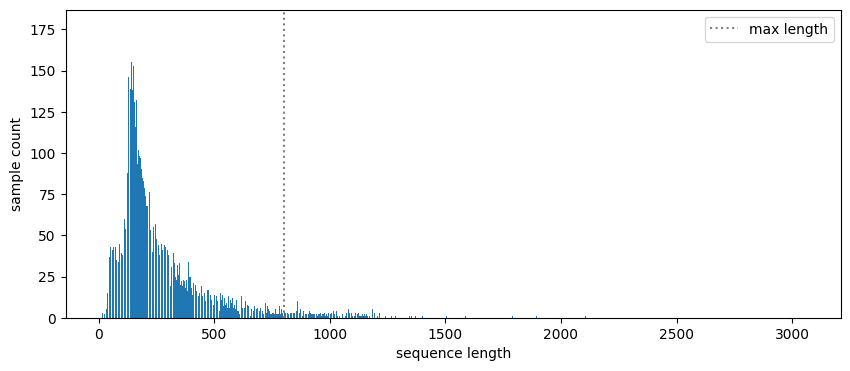

In [15]:
# 本单元目标：统计训练集序列长度分布，为 MAX_LENGTH 的选取提供数据依据。

# 长度统计字典（Dict[int, int]）：键=序列长度，值=该长度出现次数。
length_collect = {}

# 遍历训练集每个样本。
for text, label in train_ds:
    # 当前样本子词数量（int）。
    length = len(text)
    # 字典累加计数：若键不存在默认从 0 开始。
    length_collect[length] = length_collect.get(length, 0) + 1

# 设置最大序列长度（int）：超过该长度将被截断，不足将填充 PAD。
# 这里将 MAX_LENGTH 从 500 提升到 800，降低 subword 方案的信息截断损失。
MAX_LENGTH = 800

# 统计覆盖率：长度 <= MAX_LENGTH 的样本占比。
total_samples = sum(length_collect.values())
covered_samples = sum(count for seq_len, count in length_collect.items() if seq_len <= MAX_LENGTH)
covered_ratio = covered_samples / total_samples
print(f"长度<=MAX_LENGTH 的样本占比: {covered_ratio:.4f}")

# 准备绘图数据：对长度键排序，保证横轴从短到长。
sorted_lengths = sorted(length_collect.keys())
sorted_counts = [length_collect[item] for item in sorted_lengths]

# 绘制柱状图：横轴为序列长度，纵轴为样本数。
plt.figure(figsize=(10, 4))
plt.bar(sorted_lengths, sorted_counts)
# 用垂直虚线标注当前 MAX_LENGTH 位置。
plt.axvline(MAX_LENGTH, label="max length", c="gray", ls=":")
# 添加坐标轴标签提升可读性。
plt.xlabel("sequence length")
plt.ylabel("sample count")
# 显示图例。
plt.legend()
# 显示图像。
plt.show()


## 五、Tokenizer

封装 `Tokenizer` 类，提供 **编码（Encode）** 和 **解码（Decode）** 功能：
- **encode**：将子词 token 列表批量转换为固定长度的整数 id 张量（添加 BOS/EOS，截断/填充）
- **decode**：将整数 id 序列还原为可读文本

> 使用 `padding_first=True` 时填充在前（左填充），使真实内容紧靠序列末端，适配 LSTM 取最后一步隐状态的用法。

In [16]:
# 定义 Tokenizer：负责“子词序列 <-> id 序列”的双向转换。
class Tokenizer:
    # 初始化编码/解码所需词表与特殊 token id。
    def __init__(self, word2idx, idx2word, max_length=MAX_LENGTH,
                 pad_idx=0, bos_idx=1, eos_idx=3, unk_idx=2,
                 truncate_mode='adaptive'):
        """
        参数：
            word2idx (Dict[str, int]): token 到 id 的映射字典。
            idx2word (Dict[int, str]): id 到 token 的映射字典。
            max_length (int): 编码后序列最大长度（含 BOS/EOS）。
            pad_idx (int): PAD 对应 id。
            bos_idx (int): BOS 对应 id。
            eos_idx (int): EOS 对应 id。
            unk_idx (int): UNK 对应 id。
            truncate_mode (str): 超长序列截断策略，支持 'adaptive'/'head'/'tail'。

        返回：
            None。
        """
        # 保存映射字典：编码走 word2idx，解码走 idx2word。
        self.word2idx = word2idx
        self.idx2word = idx2word
        # 保存序列长度上限。
        self.max_length = max_length
        # 保存特殊 token id。
        self.pad_idx = pad_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.unk_idx = unk_idx
        # 校验并保存截断模式。
        valid_modes = {'adaptive', 'head', 'tail'}
        if truncate_mode not in valid_modes:
            raise ValueError(f"truncate_mode 必须是 {valid_modes} 之一，当前为 {truncate_mode!r}")
        self.truncate_mode = truncate_mode

    # 超长截断接口：List[int] -> List[int]（长度固定为 max_length）。
    def _truncate_to_max_length(self, token_ids, max_length):
        """
        参数：
            token_ids (List[int]): 原始 id 序列。
            max_length (int): 目标序列长度。

        返回：
            List[int]: 长度固定为 max_length 的截断结果。
        """
        # head：保留句首 token。
        if self.truncate_mode == 'head':
            return token_ids[:max_length]
        # tail：保留句尾 token。
        if self.truncate_mode == 'tail':
            return token_ids[-max_length:]
        # adaptive：在整句上做等间隔采样，兼顾头中尾信息。
        positions = np.linspace(0, len(token_ids) - 1, max_length, dtype=int)
        return [token_ids[index] for index in positions]

    # 编码接口：List[List[str]] -> Tensor[batch, seq_len]。
    def encode(self, text_list, padding_first=False):
        """
        参数：
            text_list (List[List[str]]): 批量文本，每条文本已经切分为 token 列表。
            padding_first (bool): True 表示左填充，False 表示右填充。

        返回：
            torch.Tensor: 编码后的整数张量，形状 (batch_size, seq_len)。
        """
        # 防御式检查：空 batch 无法计算 max 长度，直接抛错提示上游调用问题。
        if len(text_list) == 0:
            raise ValueError("text_list 不能为空，encode 需要至少一条样本。")

        # 计算本批次动态长度：最长样本长度 + BOS/EOS 两个位置，再裁剪到全局 max_length。
        dynamic_length = 2 + max([len(text) for text in text_list])
        max_length = min(self.max_length, dynamic_length)

        # 存储本批次每条样本的编码结果。
        indices_list = []
        # 逐样本编码。
        for text in text_list:
            # 逐 token 转 id：词表外 token 映射到 UNK。
            token_ids = [self.word2idx.get(word, self.unk_idx) for word in text]
            # 当样本长度超过限制时，按 truncate_mode 执行截断。
            if len(token_ids) > max_length - 2:
                token_ids = self._truncate_to_max_length(token_ids, max_length - 2)
            # 添加序列边界标记，形成基础序列。
            indices = [self.bos_idx] + token_ids + [self.eos_idx]

            # 根据 padding 策略补齐到同长度。
            if padding_first:
                # 左填充：PAD 在前，真实 token 靠后。
                indices = [self.pad_idx] * (max_length - len(indices)) + indices
            else:
                # 右填充：真实 token 在前，PAD 在后。
                indices = indices + [self.pad_idx] * (max_length - len(indices))

            # 写入批次结果列表。
            indices_list.append(indices)

        # 转为 LongTensor：Embedding 层要求索引类型为 long/int64。
        return torch.tensor(indices_list, dtype=torch.long)

    # 解码接口：List[List[int]] -> List[str] 或 List[List[str]]。
    def decode(self, indices_list, remove_bos=True, remove_eos=True,
               remove_pad=True, split=False):
        """
        参数：
            indices_list (List[List[int]]): 批量 id 序列。
            remove_bos (bool): 是否移除 BOS。
            remove_eos (bool): 是否在 EOS 处截断。
            remove_pad (bool): 是否在 PAD 处截断。
            split (bool): True 返回 token 列表，False 返回空格拼接字符串。

        返回：
            List[str] 或 List[List[str]]。
        """
        # 保存整个 batch 的解码结果。
        text_list = []
        # 遍历每条 id 序列。
        for indices in indices_list:
            # 保存单条样本的 token 结果。
            text = []
            # 遍历当前序列中的每个 id。
            for index in indices:
                # id 反查 token；若 id 不存在则回退为 [UNK]。
                word = self.idx2word.get(index, "[UNK]")
                # 若启用 remove_bos，则跳过 BOS。
                if remove_bos and word == "[BOS]":
                    continue
                # 若启用 remove_eos，遇到 EOS 时停止读取后续 token。
                if remove_eos and word == "[EOS]":
                    break
                # 若启用 remove_pad，遇到 PAD 时停止读取后续 token。
                if remove_pad and word == "[PAD]":
                    break
                # 收集有效 token。
                text.append(word)
            # 根据 split 选择返回 token 列表或字符串。
            text_list.append(" ".join(text) if not split else text)
        # 返回整个 batch 的解码结果。
        return text_list


# 实例化 Tokenizer：后续 DataLoader 的 collate 与调试单元都复用该对象。
# 显式指定 truncate_mode='adaptive'，与词级方案保持一致的超长处理策略。
tokenizer = Tokenizer(word2idx=word2idx, idx2word=idx2word, max_length=MAX_LENGTH, truncate_mode='adaptive')

# 构造最小示例输入：每个元素是 token 列表（List[str]）。
raw_text = [
    "hello world".split(),
    "i really liked sum@@ mer@@ sla@@ m due look a@@ ren@@ a , cur@@ ".split(),
    "this is a test".split(),
]

# 执行编码：padding_first=False 表示右填充。
indices = tokenizer.encode(raw_text, padding_first=False)

# 打印原始 token 序列，便于和编码结果对照。
print("raw text-------------------")
for raw in raw_text:
    print(raw)

# 打印编码后的 id 张量（含 BOS/EOS/PAD）。
print("indices---------------")
for index in indices:
    print(index)


raw text-------------------
['hello', 'world']
['i', 'really', 'liked', 'sum@@', 'mer@@', 'sla@@', 'm', 'due', 'look', 'a@@', 'ren@@', 'a', ',', 'cur@@']
['this', 'is', 'a', 'test']
indices---------------
tensor([   1, 8748,  210,    3,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])
tensor([   1,   12,   68,  522, 7123, 1256, 2145,  536,  836,  185,  290, 1369,
           5,    2, 1632,    3])
tensor([   1,   13,    9,    5, 2054,    3,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])


### 5.1 编码与解码功能验证

通过若干最小示例验证 `Tokenizer` 的核心接口是否行为正确，包括：词表反查、批量解码、BPE 标记还原。

In [17]:
# 本单元功能：演示“词表反查”，即从整数 id 恢复子词 token，验证 idx2word 构建正确性。
# 接口说明：dict.get(key, default) -> Any；当 key 不存在时返回 default，避免 KeyError。

# 待查询 token id（int）：可替换为任意合法 id（范围通常为 [0, vocab_size-1]）。
query_token_id = 2230
# 反向查询：若 id 存在返回对应 token(str)，否则返回占位符 "[ID_NOT_FOUND]"。
query_token = idx2word.get(query_token_id, "[ID_NOT_FOUND]")

# 结构化打印，便于教学演示和日志检索。
print("查询 id:", query_token_id)
print("对应 token:", query_token)


查询 id: 2230
对应 token: trailer


In [18]:
# 本单元功能：演示 Tokenizer.decode 的完整参数行为，观察特殊 token 是否被保留。
# 接口签名：decode(indices_list, remove_bos, remove_eos, remove_pad, split) -> List[str] / List[List[str]]。

# 将 Tensor 转为 Python 嵌套列表：Tensor.tolist() -> List[List[int]]，便于传入 decode。
indices_list = indices.tolist()

# 执行解码：本例设置 remove_* 全部为 False，目的是完整观察 [BOS]/[EOS]/[PAD] 在序列中的位置。
decode_text_list = tokenizer.decode(
    indices_list,
    remove_bos=False,
    remove_eos=False,
    remove_pad=False,
    split=False,
)

# 打印标题行，便于在 Notebook 输出区区分不同实验。
print("decode text (保留 BOS/EOS/PAD)")
# enumerate(..., start=1) 给每条解码结果加编号，提升可读性。
for row_id, decode_text in enumerate(decode_text_list, start=1):
    # 每行输出一条样本对应的解码字符串（str）。
    print(f"{row_id:02d}: {decode_text}")


decode text (保留 BOS/EOS/PAD)
01: [BOS] hello world [EOS] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
02: [BOS] i really liked sum@@ mer@@ sla@@ m due look a@@ ren@@ a [UNK] cur@@ [EOS]
03: [BOS] this is a test [EOS] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


In [19]:
# 导入正则表达式模块：re 提供模式匹配、查找、替换等文本处理接口。
import re

# 本单元功能：将 BPE 子词中的续写标记 @@ 去掉，恢复更接近原词级文本的展示形式。
# 输入字符串（str）：包含典型 BPE 片段，例如 `sum@@ mer@@ sla@@ m`。
bpe_text = "i really liked sum@@ mer@@ sla@@ m due look a@@ ren@@ a , cur@@ "

# 定义正则模式（str）：`@@\s*` 表示匹配 "@@" 以及其后 0~N 个空白字符。
bpe_suffix_pattern = r"@@\s*"
# 执行替换：re.sub(pattern, repl, string) -> str，返回删除 @@ 后的新字符串。
restored_text = re.sub(bpe_suffix_pattern, "", bpe_text)

# 先打印原始文本，再打印还原文本，便于直观对比处理效果。
print("原始 BPE 文本:", bpe_text)
print("还原后文本:", restored_text)


原始 BPE 文本: i really liked sum@@ mer@@ sla@@ m due look a@@ ren@@ a , cur@@ 
还原后文本: i really liked summerslam due look arena , cur


### 5.2 构建 DataLoader

In [20]:
# 定义 collate_fct：该函数会被 DataLoader 在“组 batch”阶段自动调用。
def collate_fct(batch):
    """
    功能：将 `IMDBDataset` 逐条返回的样本列表，整理为模型可直接输入的张量。

    参数：
        batch (List[Tuple[List[str], int]]):
            一个批次的原始样本列表。
            - 每个元素第 1 项是 token 列表（List[str]）。
            - 每个元素第 2 项是标签（int, 0/1）。

    返回：
        Tuple[torch.Tensor, torch.Tensor]
            - text_tensor: 形状 (batch_size, seq_len)，dtype=torch.int32。
            - label_tensor: 形状 (batch_size, 1)，dtype=torch.float32。
    """
    # 提取文本部分：得到 List[List[str]]，每个子列表是一条评论的子词序列。
    text_list = [item[0] for item in batch]
    # 提取标签部分：得到 List[int]，后续将转为 float 列向量以匹配 BCE 损失。
    label_list = [item[1] for item in batch]

    # 文本编码：tokenizer.encode(...) -> Tensor[batch, seq_len]；这里启用左填充以匹配当前 LSTM 读最后步策略。
    text_tensor = tokenizer.encode(text_list, padding_first=True).to(dtype=torch.int)

    # 标签编码：torch.tensor(List[int]) -> 1D Tensor，再 reshape 成 (batch_size, 1) 以对齐模型输出形状。
    label_tensor = torch.tensor(label_list).reshape(-1, 1).to(dtype=torch.float)

    # 返回值：供训练循环 `for datas, labels in train_dl` 直接解包使用。
    return text_tensor, label_tensor


# 设置 batch_size（int）：每次参数更新所使用的样本数量。
batch_size = 64

# 构建训练集 DataLoader：shuffle=True 使每轮样本顺序随机化，降低顺序偏置。
train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fct,
)
# 构建测试集 DataLoader：shuffle=False 便于评估可复现；同样使用相同 collate 逻辑。
test_dl = DataLoader(
    test_ds,
    batch_size=batch_size*2,
    shuffle=False,
    collate_fn=collate_fct,
)


## 六、定义 LSTM 模型

使用 PyTorch 构建 LSTM 文本分类器，支持以下配置：
- `num_layers`：堆叠层数（单层 / 多层 LSTM）
- `bidirectional`：单向 / 双向 LSTM

**前向传播流程：**
```
token ids → Embedding → LSTM → 取 hidden（双向拼接最后两个方向 / 单向取最后一层） → Linear → BatchNorm → ReLU → AlphaDropout → Linear → logit
```

In [21]:
# 定义 LSTM 文本分类模型：输入 token id 序列，输出二分类 logit。
class LSTM(nn.Module):
    # 构造函数：初始化模型各层与超参数。
    def __init__(
        self,
        embedding_dim: int = 128,
        hidden_dim: int = 512,
        vocab_size: int = vocab_size,
        num_layers: int = 1,
        bidirectional: bool = False,
        dropout_prob: float = 0.2,
    ) -> None:
        """
        功能：初始化 LSTM 文本分类网络结构。

        参数：
            embedding_dim (int): 词向量维度。
            hidden_dim (int): LSTM 隐状态维度。
            vocab_size (int): 词表大小（Embedding 输入空间大小）。
            num_layers (int): LSTM 纵向堆叠层数。
            bidirectional (bool): 是否启用双向 LSTM。
            dropout_prob (float): AlphaDropout 丢弃概率。

        返回：
            None。
        """
        # 调用父类初始化，注册模块所需的内部状态。
        super().__init__()

        # 记录是否双向，前向传播时需要根据该标志拼接隐藏状态。
        self.bidirectional = bidirectional
        # 记录隐藏维度，便于调试时查看模型配置。
        self.hidden_dim = hidden_dim

        # Embedding 层：把离散 id 映射到连续向量空间。
        # 输入形状：(batch_size, seq_len)。
        # 输出形状：(batch_size, seq_len, embedding_dim)。
        # 说明：此处保留属性名 embeding 是为了兼容已有训练权重键名。
        self.embeding = nn.Embedding(vocab_size, embedding_dim,padding_idx=0)

        # LSTM 层：对序列进行时序建模。
        # hidden 的形状为 (num_layers * num_directions, batch_size, hidden_dim)。
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
        )

        # 线性层输入维度：双向需要拼接最后两个方向的 hidden，单向仅取最后一层 hidden。
        linear_input_dim = hidden_dim * (2 if bidirectional else 1)

        # 第一层线性映射：句向量 -> hidden_dim。
        self.layer = nn.Linear(linear_input_dim, hidden_dim)
        # BatchNorm：按特征维归一化，提高训练稳定性。
        self.bn = nn.BatchNorm1d(hidden_dim)
        # ReLU 激活：引入非线性表达能力。
        self.relu = nn.ReLU()
        # AlphaDropout：随机失活特征，缓解过拟合。
        self.alpha_dropout = nn.AlphaDropout(p=dropout_prob)

        # 输出层：hidden_dim -> 1 个 logit（二分类）。
        self.fc = nn.Linear(hidden_dim, 1)

    # 前向传播：定义输入到输出的计算流程。
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        参数：
            x (torch.Tensor): 输入 id 张量，形状 (batch_size, seq_len)，dtype=torch.long。

        返回：
            logits (torch.Tensor): 模型原始输出分数（未经过 sigmoid）。
                - dtype: torch.float32（通常与模型参数 dtype 保持一致）
                - shape: (batch_size, 1)
        """
        # Step 1：词嵌入，将整数 id 序列转成稠密向量序列。
        x = self.embeding(x)

        # Step 2：送入 LSTM。
        # hidden 形状：(num_layers * num_directions, batch_size, hidden_dim)。
        _, (hidden, cell) = self.lstm(x)

        # Step 3：基于是否双向提取句向量。
        if self.bidirectional:
            # 双向场景：拼接最后一层的前向 hidden 与后向 hidden（即 hidden[-2] 与 hidden[-1]）。
            sentence_feature = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            # 单向场景：直接取最后一层 hidden 作为句向量。
            sentence_feature = hidden[-1]

        # Step 4：线性层 + BN + ReLU + AlphaDropout。
        hidden_feature = self.layer(sentence_feature)
        hidden_feature = self.bn(hidden_feature)
        hidden_feature = self.relu(hidden_feature)
        hidden_feature = self.alpha_dropout(hidden_feature)

        # Step 5：输出二分类 logit。
        logits = self.fc(hidden_feature)

        # 返回值 logits：torch.Tensor，shape=(batch_size, 1)，dtype 通常为 torch.float32。
        return logits


# 定义工具函数：打印模型参数统计，帮助理解不同配置的参数规模。
def print_model_parameters(model_title: str, model: nn.Module) -> None:
    """
    参数：
        model_title (str): 模型配置标题。
        model (nn.Module): 已实例化模型对象。

    返回：
        None（函数仅在标准输出打印参数统计信息，不返回数据对象）。
    """
    # 打印分隔标题，增强输出可读性。
    print("{:=^80}".format(f" {model_title} "))
    # 遍历具名参数并打印各参数张量元素个数。
    for key, value in model.named_parameters():
        param_num = int(np.prod(value.shape))
        print(f"{key:^40} parameters num: {param_num}")


# 打印一层单向 LSTM 的参数量明细。
print_model_parameters("一层单向 LSTM", LSTM())
# 打印一层双向 LSTM 的参数量明细。
print_model_parameters("一层双向 LSTM", LSTM(bidirectional=True))
# 打印两层单向 LSTM 的参数量明细。
print_model_parameters("两层单向 LSTM", LSTM(num_layers=2))


================================== 一层单向 LSTM ===================================
            embeding.weight              parameters num: 2071168
           lstm.weight_ih_l0             parameters num: 262144
           lstm.weight_hh_l0             parameters num: 1048576
            lstm.bias_ih_l0              parameters num: 2048
            lstm.bias_hh_l0              parameters num: 2048
              layer.weight               parameters num: 262144
               layer.bias                parameters num: 512
               bn.weight                 parameters num: 512
                bn.bias                  parameters num: 512
               fc.weight                 parameters num: 512
                fc.bias                  parameters num: 1
================================== 一层双向 LSTM ===================================
            embeding.weight              parameters num: 2071168
           lstm.weight_ih_l0             parameters num: 262144
           lstm.weight_h

## 七、训练

训练过程使用三个辅助回调类：
- **TensorBoardCallback**：实时可视化 loss / accuracy / learning rate
- **SaveCheckpointsCallback**：自动保存验证集最优权重
- **EarlyStopCallback**：验证指标连续不改善时提前停止

In [22]:
# 导入准确率指标函数：accuracy_score(y_true, y_pred) -> float。
from sklearn.metrics import accuracy_score

# 关闭梯度追踪：评估阶段不需要反向传播，可减少显存占用并提升推理速度。
@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    """
    功能：在验证集/测试集上评估模型，返回平均损失与准确率。

    参数：
        model (nn.Module): 已构建并可前向传播的模型对象。
        dataloader (DataLoader): 评估数据加载器，迭代返回 (datas, labels)。
        loss_fct (Callable): 损失函数接口，签名通常为 loss_fct(logits, labels) -> Tensor。

    返回：
        Tuple[float, float]
            - mean_loss: 所有 batch 损失的均值。
            - acc: 全量样本准确率。
    """
    # 用于累计每个 batch 的损失标量（float）。
    loss_list = []
    # 用于累计模型预测标签（最终传入 accuracy_score）。
    pred_list = []
    # 用于累计真实标签（最终传入 accuracy_score）。
    label_list = []
    # 切换为评估模式
    model.eval()
    # 遍历 dataloader：每次取出一个批次的输入张量与标签张量。
    for datas, labels in dataloader:
        # 将输入迁移到统一设备（CPU/GPU），保证与模型同设备。
        datas = datas.to(device)
        # 将标签迁移到统一设备，避免 loss 计算时报 device mismatch。
        labels = labels.to(device)

        # 前向传播得到 logits：形状通常为 (batch_size, 1)。
        logits = model(datas)
        # 计算该 batch 损失：返回 0 维张量（scalar tensor）。
        loss = loss_fct(logits, labels)
        # 提取 Python 标量并保存，便于后续求均值。
        loss_list.append(loss.item())

        # 由 logit 转为二分类预测：logit > 0 等价于 sigmoid(logit) > 0.5。
        preds = logits > 0
        # 将预测从 Tensor 转为 Python 列表并追加到总预测列表中。
        pred_list.extend(preds.cpu().numpy().tolist())
        # 将真实标签从 Tensor 转为 Python 列表并追加到总标签列表中。
        label_list.extend(labels.cpu().numpy().tolist())

    # 计算整体准确率：accuracy_score 接受同长度的 y_true 和 y_pred。
    acc = accuracy_score(label_list, pred_list)
    # 返回平均损失和准确率，供训练循环记录或打印。
    return np.mean(loss_list), acc


### 7.1 TensorBoard 可视化

训练过程中可用以下命令启动 TensorBoard：

```shell
tensorboard \
    --logdir=runs \     # log 文件路径
    --host 0.0.0.0 \    # ip
    --port 8848         # 端口
```

In [23]:
# 导入 TensorBoard 写入器：SummaryWriter 用于把标量、图结构等信息写入事件文件。
from torch.utils.tensorboard import SummaryWriter


# 定义训练可视化回调：统一封装 loss/acc/lr 的记录逻辑。
class TensorBoardCallback:
    """教学说明：该类在训练循环中被调用，用于把关键指标写入 TensorBoard。"""

    # 初始化回调对象：创建 SummaryWriter。
    def __init__(self, log_dir, flush_secs=10):
        """
        参数：
            log_dir (str): TensorBoard 日志目录。
            flush_secs (int): 事件缓存刷盘间隔（秒），默认 10。

        返回：
            None。
        """
        # SummaryWriter(log_dir, flush_secs) -> writer 对象。
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    # 写入模型计算图，便于在 TensorBoard Graph 页查看网络拓扑。
    def draw_model(self, model, input_shape):
        """参数 input_shape 例如 (1, MAX_LENGTH)，将用随机张量触发一次前向构图。"""
        # torch.randn(shape) 生成随机输入，add_graph 自动追踪计算图。
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    # 记录训练与验证损失曲线。
    def add_loss_scalars(self, step, loss, val_loss):
        """返回值：None；副作用是向 events 文件写入同组标量。"""
        self.writer.add_scalars(
            main_tag="training/loss",
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},
            global_step=step,
        )

    # 记录训练与验证准确率曲线。
    def add_acc_scalars(self, step, acc, val_acc):
        """返回值：None；训练和验证准确率会显示在同一图组下。"""
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        )

    # 记录学习率变化曲线。
    def add_lr_scalars(self, step, learning_rate):
        """返回值：None；通常用于观察学习率调度策略是否生效。"""
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,
        )

    # 统一入口：训练循环只需调用 callback(step, **metrics)。
    def __call__(self, step, **kwargs):
        """
        参数：
            step (int): 全局步数。
            kwargs (dict): 可选指标键，包括 loss/val_loss/acc/val_acc/lr。

        返回：
            None。
        """
        # 读取训练/验证损失；若任一缺失则不写入 loss 曲线。
        loss = kwargs.pop("loss", None)
        val_loss = kwargs.pop("val_loss", None)
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)

        # 读取训练/验证准确率；若任一缺失则不写入 accuracy 曲线。
        acc = kwargs.pop("acc", None)
        val_acc = kwargs.pop("val_acc", None)
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)

        # 读取学习率并写入曲线；若未提供则跳过。
        learning_rate = kwargs.pop("lr", None)
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)


### 7.2 保存最优权重（Save Best）

In [24]:
# 定义模型保存回调：按步数触发，支持“只保留最优模型”或“按步保存快照”。
class SaveCheckpointsCallback:
    """教学说明：该回调主要用于训练中断恢复与最优模型持久化。"""

    # 初始化保存策略与目录。
    def __init__(self, save_dir,  save_best_only=True):
        """
        参数：
            save_dir (str): 权重文件保存目录。
            save_best_only (bool): True 表示仅保存验证指标最佳模型。
        返回：
            None。
        """
        # 记录保存目录路径。
        self.save_dir = save_dir
        # 记录保存模式。
        self.save_best_only = save_best_only
        # 历史最优指标初始化为 -1（准确率场景下足够小）。
        self.best_metrics = -1

        # 若目录不存在则创建目录，确保后续 torch.save 不会报路径错误。
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)

    # 在训练循环中调用：根据 step 与 metric 决定是否保存权重。
    def __call__(self, step, state_dict, metric=None):
        """
        参数：
            step (int): 当前全局训练步数。
            state_dict (dict): 模型参数字典，通常来自 model.state_dict()。
            metric (Optional[float]): 当前评估指标（如 val_acc）。

        返回：
            None。
        """
        # 仅保存最优模式：需要 metric 参与比较。
        if self.save_best_only:
            # 若用户未传入 metric，显式报错提醒调用方。
            assert metric is not None
            # 当本次指标不低于历史最优时，覆盖 best.ckpt。
            if metric >= self.best_metrics:
                torch.save(state_dict, os.path.join(self.save_dir, "7_model_best.ckpt"))
                # 更新历史最优指标记录。
                self.best_metrics = metric
        else:
            # 全量快照模式：按 step 命名，便于回溯任意训练阶段。
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))


### 7.3 早停（Early Stop）

In [25]:
# 定义早停回调：当验证指标长期无提升时提前终止训练，避免过拟合和无效计算。
class EarlyStopCallback:
    """教学说明：该策略常用于深度学习训练，尤其在验证曲线已进入平台期时。"""

    # 初始化早停参数。
    def __init__(self, patience=5, min_delta=0.01):
        """
        参数：
            patience (int): 容忍“连续未改善”的最大次数。
            min_delta (float): 认定为“有效改善”的最小增量阈值。

        返回：
            None。
        """
        # 连续多少次未改善后触发停止。
        self.patience = patience
        # 改善幅度阈值，小于该值视为“未改善”。
        self.min_delta = min_delta
        # 历史最佳指标，首次调用时初始化。
        self.best_metric = None
        # 连续未改善计数器。
        self.counter = 0
        # 早停标志位：True 表示建议终止训练。
        self.early_stop = False

    # 每次评估后调用该方法，输入当前验证指标。
    def __call__(self, metric):
        """
        参数：
            metric (float): 当前验证指标（本项目中越大越好，如准确率）。

        返回：
            None（通过更新 self.early_stop 暴露状态）。
        """
        # 首次进入时直接记录当前指标为最佳值。
        if self.best_metric is None:
            self.best_metric = metric
        # 若提升幅度达到阈值，更新最佳值并清零计数器。
        elif metric - self.best_metric >= self.min_delta:
            self.best_metric = metric
            self.counter = 0
        else:
            # 若未达到阈值，计数器加一。
            self.counter += 1
            # 当连续未改善次数达到 patience 时，置位 early_stop。
            if self.counter >= self.patience:
                self.early_stop = True


### 7.4 训练主循环

In [26]:
%%time

# 定义训练主函数：封装“训练 + 周期验证 + 回调触发 + 记录指标”的完整流程。
def training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,
):
    """
    功能：执行多轮训练，并在固定步长上做验证评估。

    参数：
        model (nn.Module): 待训练模型。
        train_loader (DataLoader): 训练集加载器。
        val_loader (DataLoader): 验证集/测试集加载器。
        epoch (int): 训练轮数。
        loss_fct (Callable): 损失函数。
        optimizer (torch.optim.Optimizer): 优化器。
        tensorboard_callback (Optional[TensorBoardCallback]): 指标可视化回调。
        save_ckpt_callback (Optional[SaveCheckpointsCallback]): 权重保存回调。
        early_stop_callback (Optional[EarlyStopCallback]): 早停回调。
        eval_step (int): 每隔多少个 step 执行一次验证。

    返回：
        Dict[str, List[Dict[str, float]]]
            - record_dict["train"]: 训练过程记录。
            - record_dict["val"]: 验证过程记录。
    """
    # 初始化历史记录容器。
    record_dict = {"train": [], "val": []}

    # 全局步数计数器，从 0 开始累计到训练结束。
    global_step = 0
    # 切换模型到训练模式（启用 Dropout，更新 BatchNorm 统计等）。
    model.train()

    # tqdm 进度条总长度设置为“总轮数 * 每轮 batch 数”。
    with tqdm(total=epoch * len(train_loader), desc="训练进度") as pbar:
        # 外层循环：按 epoch 迭代。
        for epoch_id in range(epoch):
            # 内层循环：遍历当前 epoch 的所有训练 batch。
            for datas, labels in train_loader:
                # 训练输入迁移到设备。
                datas = datas.to(device)
                # 训练标签迁移到设备。
                labels = labels.to(device)

                # 清空上一轮累计梯度。
                optimizer.zero_grad()
                # 前向计算 logits。
                logits = model(datas)
                # 计算当前 batch 损失。
                loss = loss_fct(logits, labels)
                # 反向传播，计算参数梯度。
                loss.backward()
                # 根据梯度更新模型参数。
                optimizer.step()

                # 由 logits 生成二值预测。
                preds = logits > 0
                # 计算当前 batch 准确率（转 CPU + NumPy 后计算）。
                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
                # 将损失转为 Python float，便于日志记录。
                loss = loss.cpu().item()

                # 记录本次训练 batch 指标。
                record_dict["train"].append(
                    {"loss": loss, "acc": acc, "step": global_step}
                )

                # 达到评估步长时，执行一次验证集评估。
                if global_step % eval_step == 0:
                    # 调用 evaluating 获取验证损失与准确率。
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    # 保存验证指标到记录容器。
                    record_dict["val"].append(
                        {"loss": val_loss, "acc": val_acc, "step": global_step}
                    )
                    # 评估完成后恢复训练模式。
                    model.train()

                    # 若启用了 TensorBoard 回调，则写入 loss/acc/lr 指标。
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,
                            loss=loss,
                            val_loss=val_loss,
                            acc=acc,
                            val_acc=val_acc,
                            lr=optimizer.param_groups[0]["lr"],
                        )

                    # 若启用了检查点回调，则尝试保存当前模型。
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)

                    # 若启用了早停回调，则根据 val_acc 判断是否终止训练。
                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / step {global_step}")
                            return record_dict

                # 全局步数 +1。
                global_step += 1
                # 进度条更新 1 步。
                pbar.update(1)
                # 在进度条尾部显示当前 epoch 编号。
                pbar.set_postfix({"epoch": epoch_id})

    # 训练正常结束时返回完整记录。
    return record_dict


# 设置最大训练轮数。
epoch = 30
# 实例化模型（默认单层单向 LSTM）。
model = LSTM(num_layers=2,bidirectional=True,dropout_prob=0.65)

# 定义损失函数：BCE with logits（内部已包含 sigmoid，数值稳定性更好）。
loss_fct = F.binary_cross_entropy_with_logits

# 定义优化器：Adam，初始学习率 1e-3。
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001,weight_decay=0.05)

# # 若 runs 目录不存在则创建，用于存放 TensorBoard 事件文件。
# if not os.path.exists("runs"):
#     os.mkdir("runs")
# # 初始化 TensorBoard 回调实例。
# tensorboard_callback = TensorBoardCallback("runs/imdb-lstm-subword")

# 初始化检查点回调：每个 epoch 评估后检查一次是否需要更新 best.ckpt。
save_ckpt_callback = SaveCheckpointsCallback(
    "model_checkpoints/7_model",
    save_best_only=True,
)

# 初始化早停回调：若连续 10 次评估无明显改善则提前停止训练。
early_stop_callback = EarlyStopCallback(patience=15)

# 将模型迁移到目标设备。
model = model.to(device)
eval_step=len(train_dl)//2
# 启动训练流程并接收记录字典。
record = training(
    model,
    train_dl,
    test_dl,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=early_stop_callback,
    eval_step=eval_step,
)


训练进度:  40%|███▉      | 4680/11730 [25:34<38:31,  3.05it/s, epoch=11]   

Early stop at epoch 11 / step 4680
CPU times: total: 8h 15min 13s
Wall time: 25min 34s


### 7.5 绘制学习曲线

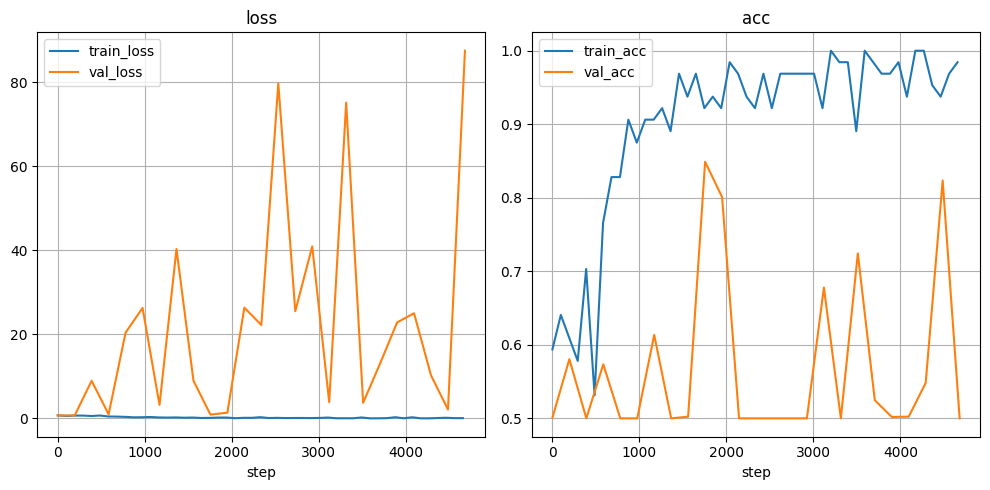

In [27]:
# 教学提示：loss 曲线通常“总体下降但有波动”，不要求严格单调递减。
def plot_learning_curves(record_dict, sample_step=500):
    """
    功能：绘制训练/验证集的 loss 和 accuracy 曲线，便于观察收敛与泛化趋势。

    参数：
        record_dict (dict): `training()` 返回的记录字典，需包含 train/val 两组数据。
        sample_step (int): 训练曲线下采样步长，值越大绘图越快但细节更少。

    返回：
        None（函数通过 Matplotlib 直接渲染图像）。
    """
    # 训练记录转 DataFrame，并按 step 作为索引。
    train_df = pd.DataFrame(record_dict["train"]).set_index("step")
    # 对训练点做下采样，减少可视化点数。
    train_df = train_df.iloc[::sample_step]
    # 验证记录通常点更少，直接全量绘制。
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # 指标列数量，通常为 2（loss 与 acc）。
    fig_num = len(train_df.columns)
    # 创建横向子图画布。
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))

    # 若仅有一个指标，Matplotlib 返回单 Axes 对象；统一包装为列表便于下标访问。
    if fig_num == 1:
        axs = [axs]

    # 逐指标绘制 train 与 val 两条曲线。
    for idx, metric_name in enumerate(train_df.columns):
        # 绘制训练曲线。
        axs[idx].plot(train_df.index, train_df[metric_name], label=f"train_{metric_name}")
        # 绘制验证曲线。
        axs[idx].plot(val_df.index, val_df[metric_name], label=f"val_{metric_name}")
        # 设置网格便于读数。
        axs[idx].grid()
        # 设置图例说明曲线含义。
        axs[idx].legend()
        # 设置横轴标签。
        axs[idx].set_xlabel("step")
        # 设置子图标题为当前指标名。
        axs[idx].set_title(metric_name)

    # 自动调整布局，避免文字重叠。
    plt.tight_layout()
    # 显示图像。
    plt.show()

sample_step=eval_step//2
# 调用绘图函数：sample_step=10 表示训练曲线每 10 个点取一个用于显示。
plot_learning_curves(record, sample_step)


## 八、推理与评估

In [28]:
# 本单元目标：完成最终测试评估（加载最优权重 -> 推理模式 -> 计算测试集指标 -> 输出结果）。

# 定义最优权重路径（str）：由 SaveCheckpointsCallback 在训练过程中生成。
best_ckpt_path = "model_checkpoints/7_model/7_model_best.ckpt"
# 读取权重文件：torch.load(path, map_location='cpu') -> dict[str, Tensor]。
# map_location='cpu' 让该代码在无 GPU 机器上也能安全加载。
best_state_dict = torch.load(best_ckpt_path, map_location="cpu")

# 加载参数到当前模型实例：返回 _IncompatibleKeys（用于检查键是否匹配）。
load_result = model.load_state_dict(best_state_dict)
# 打印加载结果：正常情况下 missing_keys 和 unexpected_keys 均应为空。
print("权重加载结果:", load_result)


# 执行测试评估：evaluating(...) -> (loss, acc)。
loss, acc = evaluating(model, test_dl, loss_fct)

# 规范化打印评估结果：保留四位小数，便于实验对比与记录。
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")


权重加载结果: <All keys matched successfully>
loss:     0.8934
accuracy: 0.8489
